# Centralized Model (Baseline)

In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from train import task
from exploration import exploration_utils
import centralized_utils

## Data

In [2]:
from torchvision import models
import pandas as pd

In [3]:
data_dir_a = "../../data/hospital_a/"
data_dir_b = "../../data/hospital_b/"
data_dir_c = "../../data/hospital_c/"

train_filenames = 'train-*.parquet'
eval_filenames = 'eval-*.parquet'

data_paths = [data_dir_a, data_dir_b, data_dir_c]

df_train_combined = centralized_utils.get_hospitals_df(data_paths, train_filenames)
df_eval_combined = centralized_utils.get_hospitals_df(data_paths, eval_filenames)

### Double checking size is correct

In [4]:
# Get train/val DataFrames for each hospital
data_dir_a = '../../data/hospital_a/'
train_filenames = 'train-*.parquet'
eval_filenames = 'eval-*.parquet'

df_train_a, df_eval_a, df_combined_a = exploration_utils.get_hospital_dfs(data_dir_a, train_filenames, eval_filenames)
len(df_train_a), len(df_eval_a)

data_dir_b = '../../data/hospital_b/'

df_train_b, df_eval_b, df_combined_b = exploration_utils.get_hospital_dfs(data_dir_b, train_filenames, eval_filenames)
len(df_train_b), len(df_eval_b)

data_dir_c = '../../data/hospital_c/'

df_train_c, df_eval_c, df_combined_c = exploration_utils.get_hospital_dfs(data_dir_c, train_filenames, eval_filenames)
len(df_train_c), len(df_eval_c);

In [5]:
print(len(df_train_combined) == len(df_train_a) + len(df_train_b) + len(df_train_c))

train_info = {
    '# of Examples in Hospital A': [f'{len(df_train_a):,}'],
    '# of Examples in Hospital B': [f'{len(df_train_b):,}'],
    '# of Examples in Hospital C': [f'{len(df_train_c):,}'],
    'Total Number of Examples': [f'{len(df_train_combined):,}']
}
train_info = pd.DataFrame.from_dict(train_info, orient='index', columns=['Count'])
train_info

True


,Count
# of Examples in Hospital A,"2,380"
# of Examples in Hospital B,"2,322"
# of Examples in Hospital C,"2,363"
Total Number of Examples,"7,065"


In [6]:
print(len(df_eval_combined) == len(df_eval_a) + len(df_eval_b) + len(df_eval_c))

eval_info = {
    '# of Examples in Hospital A': [f'{len(df_eval_a):,}'],
    '# of Examples in Hospital B': [f'{len(df_eval_b):,}'],
    '# of Examples in Hospital C': [f'{len(df_eval_c):,}'],
    'Total Number of Examples': [f'{len(df_eval_combined):,}']
}
eval_info = pd.DataFrame.from_dict(eval_info, orient='index', columns=['Count'])
eval_info

True


,Count
# of Examples in Hospital A,310
# of Examples in Hospital B,306
# of Examples in Hospital C,312
Total Number of Examples,928


### Data Visualization (Preprocessing vs. No-preprocessing)

Desnet121 requires the following data preprocessing:

In [7]:
weights = models.DenseNet121_Weights.DEFAULT
preprocess_transform = weights.transforms()
preprocess_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [8]:
train_preprocessed = task.XrayDataset(df_train_combined, transform=preprocess_transform)
train_not_preprocessed = task.XrayDataset(df_train_combined, transform=None)

In [9]:
pre_img, pre_label = train_preprocessed[4]
not_img, not_label = train_not_preprocessed[4]

#### Preprocessed

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1345534].


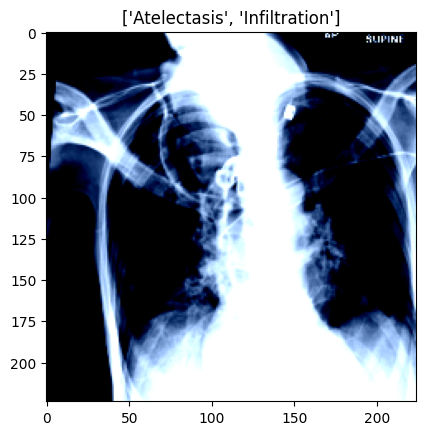

In [10]:
centralized_utils.show_xray(pre_img.permute(1, 2, 0), pre_label)

#### Not Preprocessed

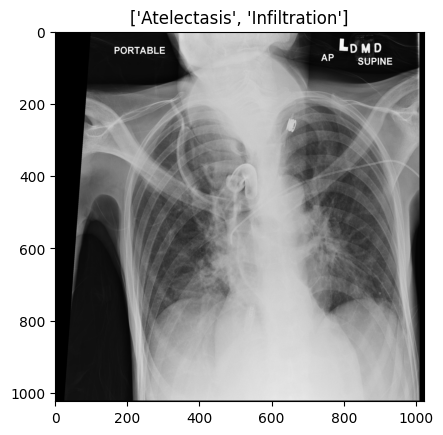

In [11]:
centralized_utils.show_xray(not_img, not_label)

## Model & Training Loop

In [13]:
import torch

In [14]:
class DenseNet121(torch.nn.Module):
    def __init__(self, n_classes, device='cpu'):
        super().__init__()
        self.device = device
        self.densenet121 = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.densenet121.classifier = torch.nn.Linear(self.densenet121.classifier.in_features, n_classes)
        self.to(self.device)
    def forward(self, X):
        return self.densenet121(X)

In [15]:
n_classes = 14
densenet121 = DenseNet121(n_classes, device='cpu')
densenet121

DenseNet121(
  (densenet121): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, mome

In [16]:
def train(model, train_loader, epochs, learning_rate=0.001):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    total_train_loss = []
    
    for epoch in range(epochs):
        train_loss = 0.0
        model.train()
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for i, (images, labels) in enumerate(pbar):
            images, labels = images.to(device), labels.to(device)
        
            logits = model(images)
            loss = criterion(logits, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        avg_train_loss = train_loss / len(train_loader)
        print(f'Epoch {epoch+1} average loss: {avg_train_loss:.4f}')
        total_train_loss.append(avg_train_loss)

    return total_train_loss

In [17]:
device = 'cpu'
if torch.cuda.is_available():
    device = torch.device('cuda:0')
print('Running on', device)

Running on cuda:0


## Training

In [18]:
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm import tqdm

In [19]:
n_epochs = 10
batch_size = 32
learning_rate = 0.001

n_classes = 14
densenet121 = DenseNet121(n_classes, device=device)

train_dataset = task.XrayDataset(df_train_combined, transform=preprocess_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

total_train_loss = train(densenet121, train_loader, n_epochs, learning_rate);

Epoch 1/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [03:14<00:00,  1.14it/s]


Epoch 1 average loss: 0.1806


Epoch 2/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [03:14<00:00,  1.14it/s]


Epoch 2 average loss: 0.1696


Epoch 3/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [03:15<00:00,  1.13it/s]


...

Epoch 8 average loss: 0.1556


Epoch 9/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [02:36<00:00,  1.41it/s]


Epoch 9 average loss: 0.1522


Epoch 10/10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [02:37<00:00,  1.40it/s]

Epoch 10 average loss: 0.1496


## Metrics

### Plot Loss

In [20]:
from matplotlib import pyplot as plt

In [21]:
def plot_loss(loss_train):
    """
    Plot loss curve of train set.
    """
    plt.figure(figsize=(5,3))
    plt.plot(range(1, len(loss_train)+1), loss_train, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='best')
    plt.show()

### Test Eval

In [22]:
from sklearn.metrics import jaccard_score, f1_score, recall_score, precision_score, roc_auc_score
import numpy as np

In [23]:
def jaccard_similarity(y_actual, y_pred):
    scores = []
    for actual, pred in zip(y_actual, y_pred):
        union = np.sum(np.logical_or(actual, pred))
        if union == 0:
            scores.append(1.0)
        else:
            scores.append(jaccard_score(actual, pred, average='binary'))
    return np.mean(scores)
    
def evaluation_metrics(model, test_loader, device, threshold=0.5):
    actual = []
    pred = []
    probs_all = []
    
    model.eval()
    pbar = tqdm(test_loader, desc=f"Evaluating")
    for (images, labels) in pbar:
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            logits = model(images)

            probs = torch.sigmoid(logits)

            y_pred = (probs > threshold).int().cpu().numpy()
            y_actual = labels.cpu().numpy()
    
            actual.append(y_actual)
            pred.append(y_pred)
            probs_all.append(probs.cpu().numpy())
    actual = np.vstack(actual)
    pred = np.vstack(pred)
    probs_all = np.vstack(probs_all)
            
    jaccard = jaccard_similarity(actual, pred)
    f1 = f1_score(actual, pred, average='macro', zero_division=0)
    recall = recall_score(actual, pred, average='macro', zero_division=0)
    precision = precision_score(actual, pred, average='macro', zero_division=0)
    roc_auc = roc_auc_score(actual, probs_all, average='macro')
    
    results = {
        'Jaccard Similarity': jaccard,
        'F1-score': f1, 
        'Recall': recall,
        'Precision': precision,
        'roc_auc': roc_auc
    }
    return results

## Evaluation

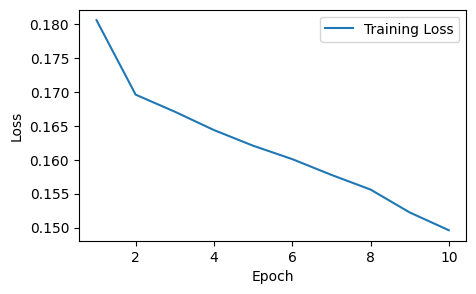

In [24]:
plot_loss(total_train_loss)

In [25]:
eval_dataset = task.XrayDataset(df_eval_combined, transform=preprocess_transform)
eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

results = evaluation_metrics(densenet121, eval_loader, device);

Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:17<00:00,  1.67it/s]


In [26]:
results = pd.DataFrame([results])
results

,Jaccard Similarity,F1-score,Recall,Precision,roc_auc
0,0.548761,0.062648,0.037769,0.248055,0.731444
